In [1]:
from google.colab import drive
import sys

# Mount Google Drive
drive.mount('/content/drive')

# Add the folder containing data_utils.py to the system path
sys.path.append('/content/drive/MyDrive/data')

Mounted at /content/drive


In [2]:
# --- Standard Libraries ---
import os
import cv2
import sys
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# --- Custom Utilities ---
from data_utils import (
    load_sample_dataframe_from_dir,
    load_dataset_from_df,
    load_dataset_from_dir,
    balance_data
)


## Create VGG Model


In [3]:
# Function to create VGG Model
def create_vgg_model(input_shape, num_classes):

  # Load the pre-trained VGG16 model (without the top layer)
  vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

  # Freeze all layers except the last few
  for layer in vgg_base.layers[:-4]:
      layer.trainable = False

  # Add a custom classification head
  x = Flatten()(vgg_base.output)
  x = Dense(256, activation='relu')(x)
  x = Dropout(0.5)(x)
  x = Dense(1, activation='sigmoid')(x)  # Binary classification (Normal vs. Pneumonia)

  # Create the model
  model = Model(inputs=vgg_base.input, outputs=x)

  # Compile the model
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                loss='binary_crossentropy',
                metrics=['accuracy', 'precision', 'recall'])
  return model


In [4]:
num_epochs = 30

def train_and_evaluate(model, train_ds, val_ds, test_ds, test_description="example_test"):
    results_path = f"{test_description}_results.csv"

    # Callbacks for training
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, verbose=1)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=num_epochs,
        callbacks=[lr_scheduler, early_stopping]
    )

    # Reset test_ds if applicable
    if hasattr(test_ds, 'reset'):
        test_ds.reset()

    # Predictions (fixed to go through test set exactly once)
    y_true, y_pred = [], []
    steps = test_ds.samples // test_ds.batch_size
    if test_ds.samples % test_ds.batch_size != 0:
        steps += 1

    for i in range(steps):
        images, labels = next(test_ds)
        predictions = model.predict(images, verbose=0)
        binary_preds = (predictions > 0.6).astype(int).flatten()
        y_true.extend(labels.astype(int))
        y_pred.extend(binary_preds)

    # Metrics
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    report = classification_report(y_true, y_pred, output_dict=True)
    class_0_precision = report['0']['precision']
    class_0_recall = report['0']['recall']
    class_1_precision = report['1']['precision']
    class_1_recall = report['1']['recall']

    results_df = pd.DataFrame({
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1],
        'Class_0_Precision': [class_0_precision],
        'Class_0_Recall': [class_0_recall],
        'Class_1_Precision': [class_1_precision],
        'Class_1_Recall': [class_1_recall]
    })

    results_df.to_csv(results_path, index=False)
    print("Metrics saved to", results_path)
    print(classification_report(y_true, y_pred))
    return history, y_true, y_pred, results_df

In [5]:
# Function to visualize results
def plot_results(history, y_true, y_pred, test_description):
    # accuracy metric
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.title('Training & Validation Accuracy')
    plt.savefig(f"{test_description}_accuracy.png")

    # loss function
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Training & Validation Loss')
    plt.savefig(f"{test_description}_loss.png")

    # recall metric
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['recall'], label='Train Recall')
    plt.plot(history.history['val_recall'], label='Val Recall')
    plt.legend()
    plt.title('Training & Validation Recall')
    plt.savefig(f"{test_description}_recall.png")

    plt.show()

## Load Data

In [16]:
model = create_vgg_model(input_shape=(128, 128, 3), num_classes=2)
model.save("vgg16_chest_xray.keras")

In [17]:
# Use Kaggle data as base

# --- Paths ---
normal_data_path = '/content/drive/MyDrive/data/chest_xray/train/NORMAL'
pneumonia_data_path = '/content/drive/MyDrive/data/chest_xray/train/PNEUMONIA'
test_data_path = '/content/drive/MyDrive/data/chest_xray/test'

# --- Build and split DataFrames ---
train_df = pd.DataFrame(columns=['filename', 'class'])
train_df = load_sample_dataframe_from_dir(train_df, normal_data_path, 'NORMAL', sample_size=1341, seed=42)
train_df = load_sample_dataframe_from_dir(train_df, pneumonia_data_path, 'PNEUMONIA', sample_size=3875, seed=42)

# Stratified train/val split
search_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['class'], random_state=42)

# --- Create datasets ---
search_ds = load_dataset_from_df(search_df, "filename", "class", img_size=(128, 128), batch_size=32, color_mode='rgb')
val_ds = load_dataset_from_df(val_df, "filename", "class", img_size=(128, 128), batch_size=32, color_mode='rgb')
test_ds = load_dataset_from_dir(test_data_path, img_size=(128, 128), batch_size=32, gaussian_blur=False, color_mode='rgb')

Found 4172 validated image filenames belonging to 2 classes.
Found 1044 validated image filenames belonging to 2 classes.
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 731s 5s/step - accuracy: 0.9000 - loss: 0.2313 - precision: 0.9223 - recall: 0.9468 - val_accuracy: 0.9722 - val_loss: 0.0755 - val_precision: 0.9758 - val_recall: 0.9871 - learning_rate: 1.0000e-04
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 77s 585ms/step - accuracy: 0.9730 - loss: 0.0762 - precision: 0.9806 - recall: 0.9826 - val_accuracy: 0.9684 - val_loss: 0.0804 - val_precision: 0.9921 - val_recall: 0.9652 - learning_rate: 1.0000e-04
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 76s 580ms/step - accuracy: 0.9815 - loss: 0.0509 - precision: 0.9901 - recall: 0.9851 - val_accuracy: 0.9741 - val_loss: 0.0669 - val_precision: 0.9934 - val_recall: 0.9716 - learning_rate: 1.0000e-04
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 75s 578ms/step - accuracy: 0.9855 - loss: 0.0349 - precision: 0.9888 - recall: 0.9917 - val_accuracy: 0.9751 - val_loss: 0.0639 - val_precision: 0.9711 - val_recall: 0.9961 - learning_rate: 1.0000e-04
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━

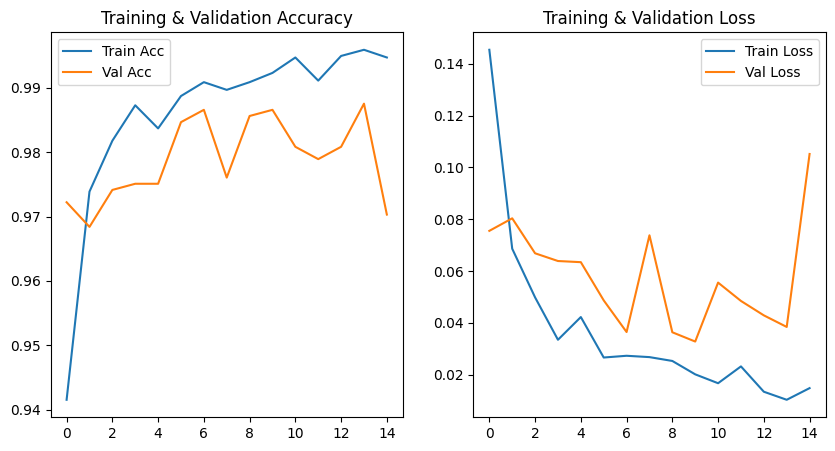

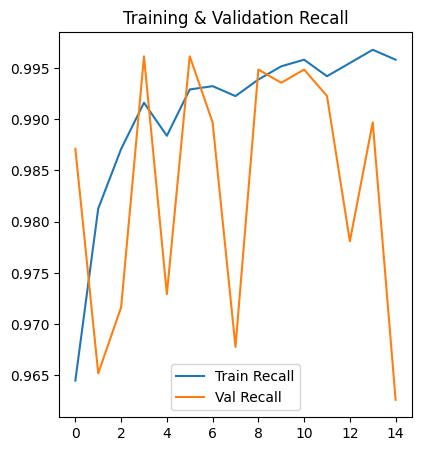

In [8]:
# Evaluate the best model from the tuner
test_description = "tuned_cnn_vanilla"

history, y_true, y_pred, results_df = train_and_evaluate(
    model=model,
    train_ds=search_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    test_description=test_description
)

plot_results(history, y_true, y_pred, test_description)

Found 2145 validated image filenames belonging to 2 classes.
Found 537 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 56s 819ms/step - accuracy: 0.9957 - loss: 0.0138 - precision: 0.9942 - recall: 0.9973 - val_accuracy: 0.9963 - val_loss: 0.0094 - val_precision: 1.0000 - val_recall: 0.9925 - learning_rate: 3.0000e-05
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 48s 701ms/step - accuracy: 0.9963 - loss: 0.0102 - precision: 0.9973 - recall: 0.9953 - val_accuracy: 0.9963 - val_loss: 0.0102 - val_precision: 0.9963 - val_recall: 0.9963 - learning_rate: 3.0000e-05
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 48s 702ms/step - accuracy: 0.9987 - loss: 0.0066 - precision: 0.9995 - recall: 0.9978 - val_accuracy: 0.9944 - val_loss: 0.0138 - val_precision: 1.0000 - val_recall: 0.9888 - learning_rate: 3.0000e-05
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 47s 691ms/step - accuracy: 0.9994 - loss: 0.0035 - precision: 1.0000 - recall: 0.9987 - val_accuracy: 0.9907 - val_loss: 0.0179 - val_precision: 0.9817 - val_recall: 1.0000 - learning_rate: 3.0000e-05
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 47s 69

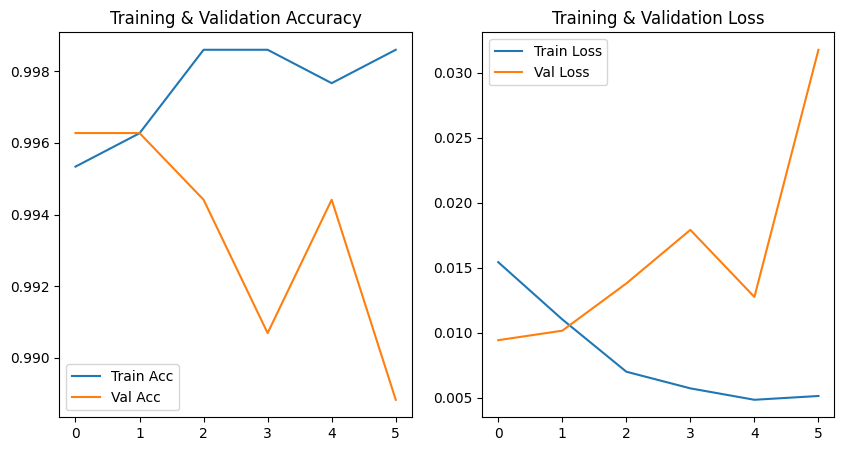

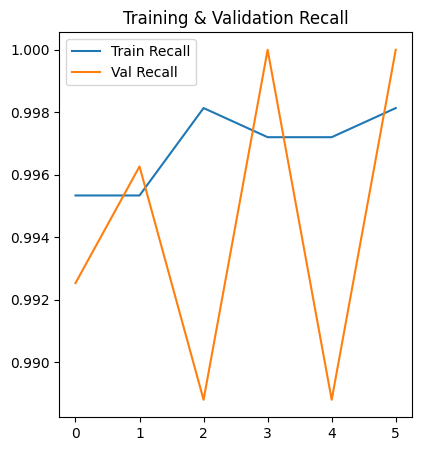

In [10]:
# Balance the training data
balanced_train_df = balance_data('/content/drive/MyDrive/data/chest_xray/train')

# Split into new search/val sets
search_df_bal, val_df_bal = train_test_split(
    balanced_train_df,
    test_size=0.2,
    stratify=balanced_train_df['class'],
    random_state=42
)

# Create balanced datasets
train_ds_bal = search_ds_bal = load_dataset_from_df(search_df_bal, "filename", "class", img_size=(128, 128), batch_size=32,color_mode='rgb')
val_ds_bal = load_dataset_from_df(val_df_bal, "filename", "class", img_size=(128, 128), batch_size=32, color_mode='rgb')

# Evaluate best model on balanced data
test_description = "tuned_cnn_balanced"

history_bal, y_true_bal, y_pred_bal, results_df_bal = train_and_evaluate(
    model=model,
    train_ds=train_ds_bal,
    val_ds=val_ds_bal,
    test_ds=test_ds,
    test_description=test_description
)

plot_results(history_bal, y_true_bal, y_pred_bal, test_description)

In [18]:
# --- Paths ---
acgan_data_path = '/content/drive/MyDrive/data/ACGAN'
test_data_path = '/content/drive/MyDrive/data/chest_xray/test'

# --- Build full dataframe from ACGAN synthetic data ---
acgan_df = balance_data(acgan_data_path)  # Balanced already (1000 each, just standardizing flow)

# --- Split into train and val ---
train_df_acgan, val_df_acgan = train_test_split(
    acgan_df,
    test_size=0.2,
    stratify=acgan_df['class'],
    random_state=42
)

# --- Create datasets ---
train_ds_acgan = load_dataset_from_df(train_df_acgan, "filename", "class", img_size=(128, 128), batch_size=32, color_mode='rgb')
val_ds_acgan = load_dataset_from_df(val_df_acgan, "filename", "class", img_size=(128, 128), batch_size=32, color_mode='rgb')
test_ds = load_dataset_from_dir(test_data_path, img_size=(128, 128), batch_size=32, gaussian_blur=False, color_mode='rgb')

Found 1600 validated image filenames belonging to 2 classes.
Found 400 validated image filenames belonging to 2 classes.
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.7085 - loss: 0.5177 - precision: 0.6988 - recall: 0.7312 - val_accuracy: 0.9425 - val_loss: 0.1488 - val_precision: 0.9155 - val_recall: 0.9750 - learning_rate: 1.0000e-04
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 294ms/step - accuracy: 0.9530 - loss: 0.1367 - precision: 0.9375 - recall: 0.9699 - val_accuracy: 0.9450 - val_loss: 0.1378 - val_precision: 0.9890 - val_recall: 0.9000 - learning_rate: 1.0000e-04
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 286ms/step - accuracy: 0.9460 - loss: 0.1306 - precision: 0.9407 - recall: 0.9476 - val_accuracy: 0.9775 - val_loss: 0.0849 - val_precision: 0.9569 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - accuracy: 0.9820 - loss: 0.0524 - precision: 0.9775 - recall: 0.9880 - val_accuracy: 0.9825 - val_loss: 0.0503 - val_precision: 0.9898 - val_recall: 0.9750 - learning_rate: 1.0000e-04
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 28

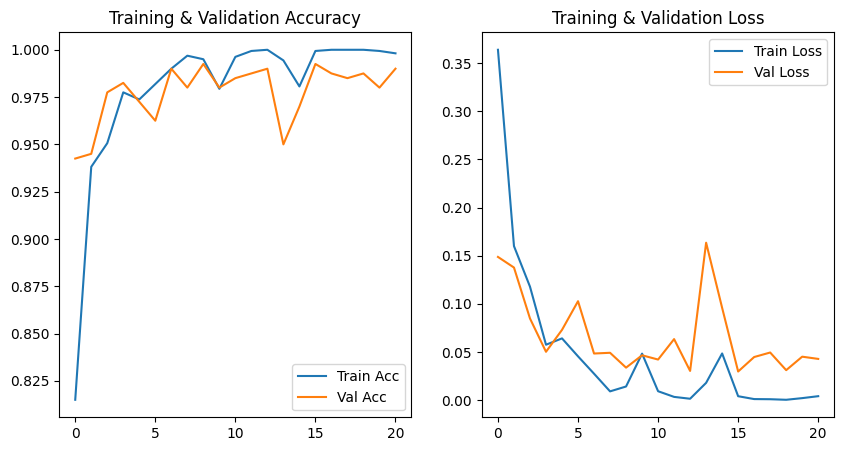

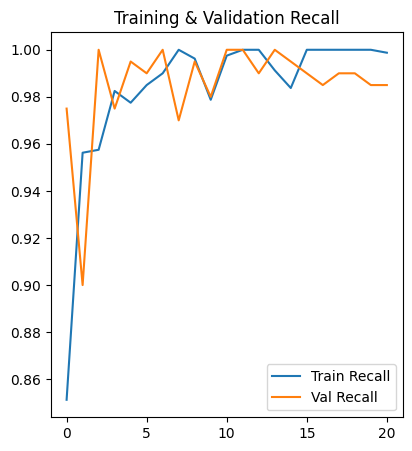

In [19]:
# Train and evaluate using synthetic (ACGAN) training data
test_description = "tuned_cnn_acgan"

history_acgan, y_true_acgan, y_pred_acgan, results_df_acgan = train_and_evaluate(
    model=model,
    train_ds=train_ds_acgan,
    val_ds=val_ds_acgan,
    test_ds=test_ds,
    test_description=test_description
)

plot_results(history_acgan, y_true_acgan, y_pred_acgan, test_description)